# Assignment 5: Local Features and Image Matching

**Overview:**

In this assignment, we will extract several basic image features (both global and local). We will match local features to locate objects in images, as well as use local features for image stitching.

* Harris Corner
* Histogram of Oriented Gradients (HOG)
* Difference of Gaussians (DoG)
* Scale-Invariant Feature Transform (SIFT)
* Local feature matching
* Panorama stitching using the OpenCV Stitcher

**Required libraries:** `skimage`, `opencv-contrib-python` (for SURF)


(pip uninstall opencv-python
pip uninstall opencv-contrib-python
pip install opencv-python=...
pip install opencv-contrib-python==3.4.2.17) # if need to change the version

In [27]:
!pip install scikit-image
!pip install opencv-contrib-python


In [28]:
from IPython.display import Image
from skimage.feature import hog
import skimage
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np


# print (cv2. __version__) 

## I. Harris Corner Detector

Harris Corner is a method for detecting corner points (salient points) in an image, and it is commonly used when computing image features for computer vision tasks.

The OpenCV library provides the function **`cv2.cornerHarris()`** to detect corner points in an image. Its parameters are as follows:

* **`img`** – Input image, which must be in grayscale and of type `float32`
* **`blockSize`** – The size of the neighborhood considered for corner detection
* **`ksize`** – Aperture parameter of the Sobel derivative used
* **`k`** – Harris detector free parameter in the equation


https://docs.opencv.org/3.0-beta/doc/py_tutorials/py_feature2d/py_features_harris/py_features_harris.html


## Please complete the function **`detect_corner()`** with the following specifications:

**Input:**

* **`image_path`**: path to the input image file
* **`blockSize`**, **`ksize`**, **`k`**: parameters of the `cv2.cornerHarris()` function
* **`threshold`**: threshold to consider a point as a corner

**Output:**

* The path to the output image file


In [29]:
def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray,blockSize,ksize,k)

    #result is dilated for marking the corners, not important
    dst = cv2.dilate(dst,None)

    # Threshold for an optimal value, it may vary depending on the image.
    img[dst>threshold*dst.max()]=[0,0,255]
    
    # output file
    relative_path, image_basename = os.path.split(image_path)
    output_file = os.path.join(relative_path, 'corner_'+image_basename)
    
    cv2.imwrite(output_file,img)
    return output_file

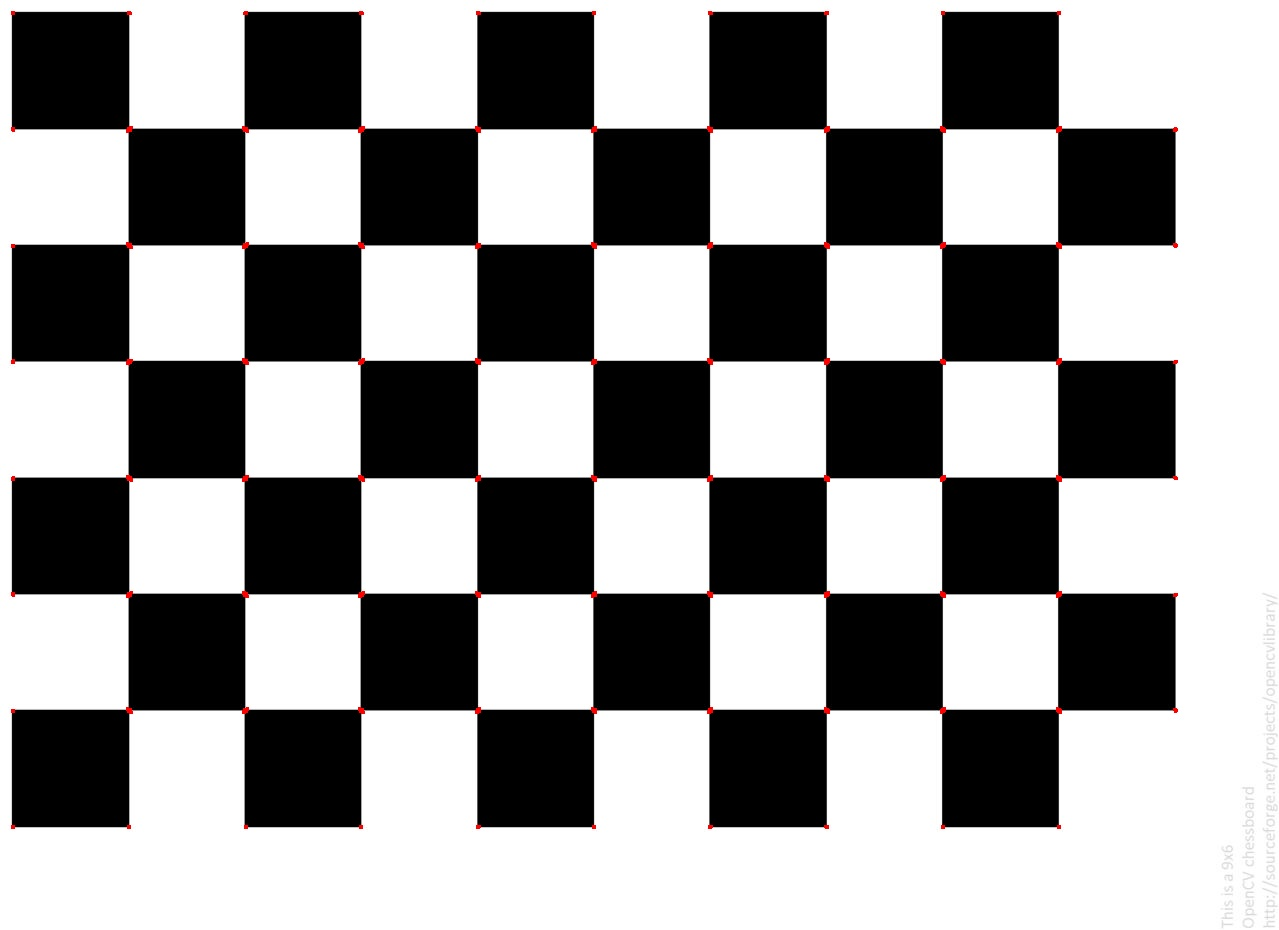

In [30]:
out_path = detect_corner('images/chessboard.jpg')

Image(out_path)

### Try tuning the parameters of the detect_corner() function on the images house.jpg and sudoku.png so that the output images detect as many accurate corners as possible.

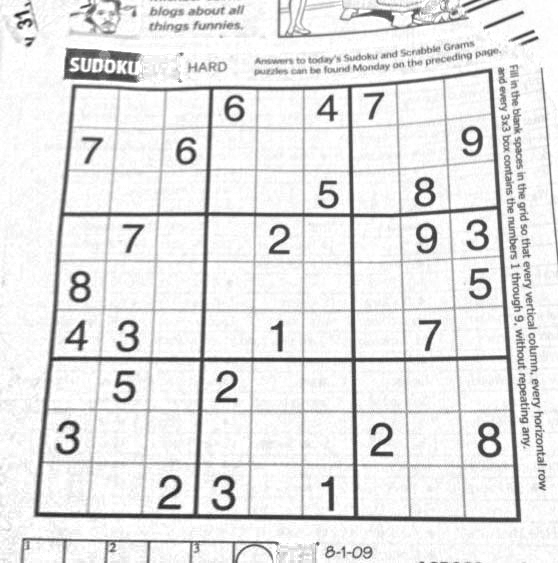

In [31]:
Image('images/sudoku.png')

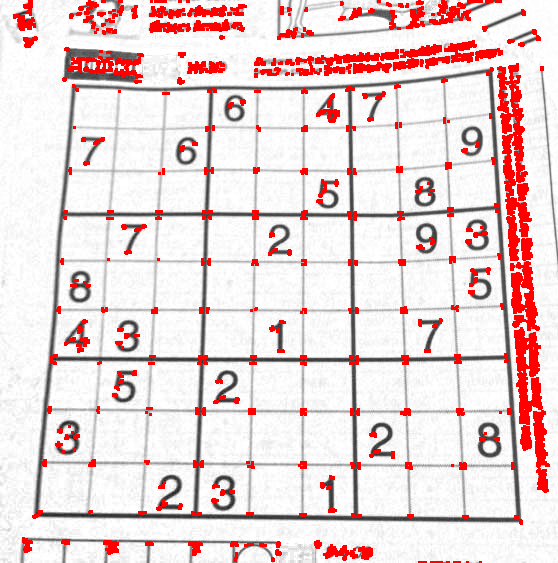

In [32]:
out_path = detect_corner('images/sudoku.png' , blockSize=2, ksize=3, k=0.04, threshold=0.01)
Image(out_path)

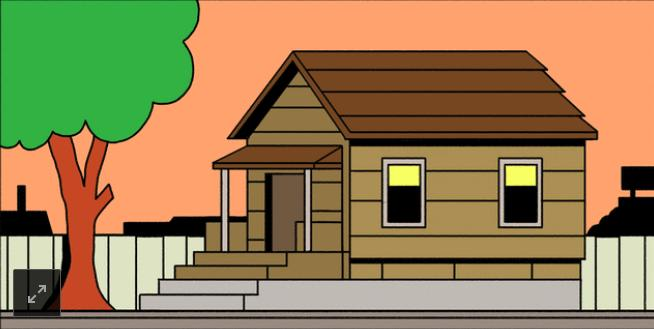

In [33]:
Image('images/house.jpg')

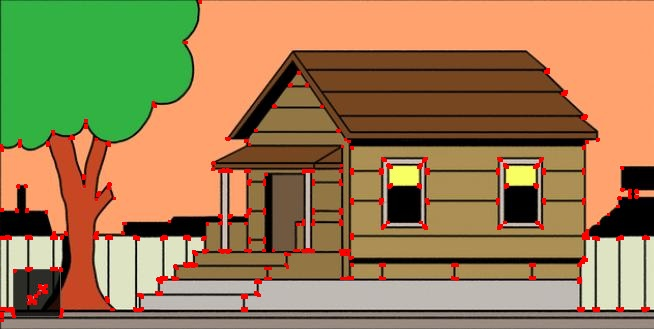

In [34]:
out_path = detect_corner('images/house.jpg')
Image(out_path)

## II. Histogram of Oriented Gradients (HOG) – An example of global features

Histogram of Oriented Gradients (HOG) is a feature descriptor commonly used to represent objects in images.

The **scikit-image (skimage)** library provides the function **`skimage.feature.hog()`** to extract HOG features. Some important parameters of this function are:

* **`orientations`**: Number of orientation bins
* **`pixels_per_cell`**: Size (in pixels) of a cell
* **`cells_per_block`**: Number of cells in each block

See full documentation at:
[http://scikit-image.org/docs/dev/api/skimage.feature.html#skimage.feature.hog](http://scikit-image.org/docs/dev/api/skimage.feature.html#skimage.feature.hog)

Detailed HOG tutorial:
[https://www.learnopencv.com/histogram-of-oriented-gradients/](https://www.learnopencv.com/histogram-of-oriented-gradients/)


(3696,)
(348, 352, 3)


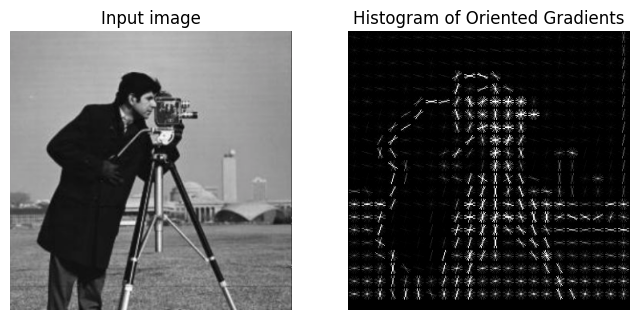

In [35]:
image = cv2.imread('images/man.png')

#fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16),
#                    cells_per_block=(1, 1), visualize=True, multichannel=True)


fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True, channel_axis=2) #channel_axis was added in 0.19 skimage

# Descriptor shape 
print(fd.shape)
print(image.shape)

# Show des inout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = skimage.exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

HOG Feature Descriptor Shapes:
Image 1: (2048,)
Image 2: (2048,)
Image 3: (2048,)

Euclidean Distance (smaller = more similar):
Image1 vs Image2: 7.05
Image1 vs Image3: 9.30
Image2 vs Image3: 9.02

Cosine Similarity (closer to 1 = more similar):
Image1 vs Image2: 0.9022
Image1 vs Image3: 0.8297
Image2 vs Image3: 0.8410


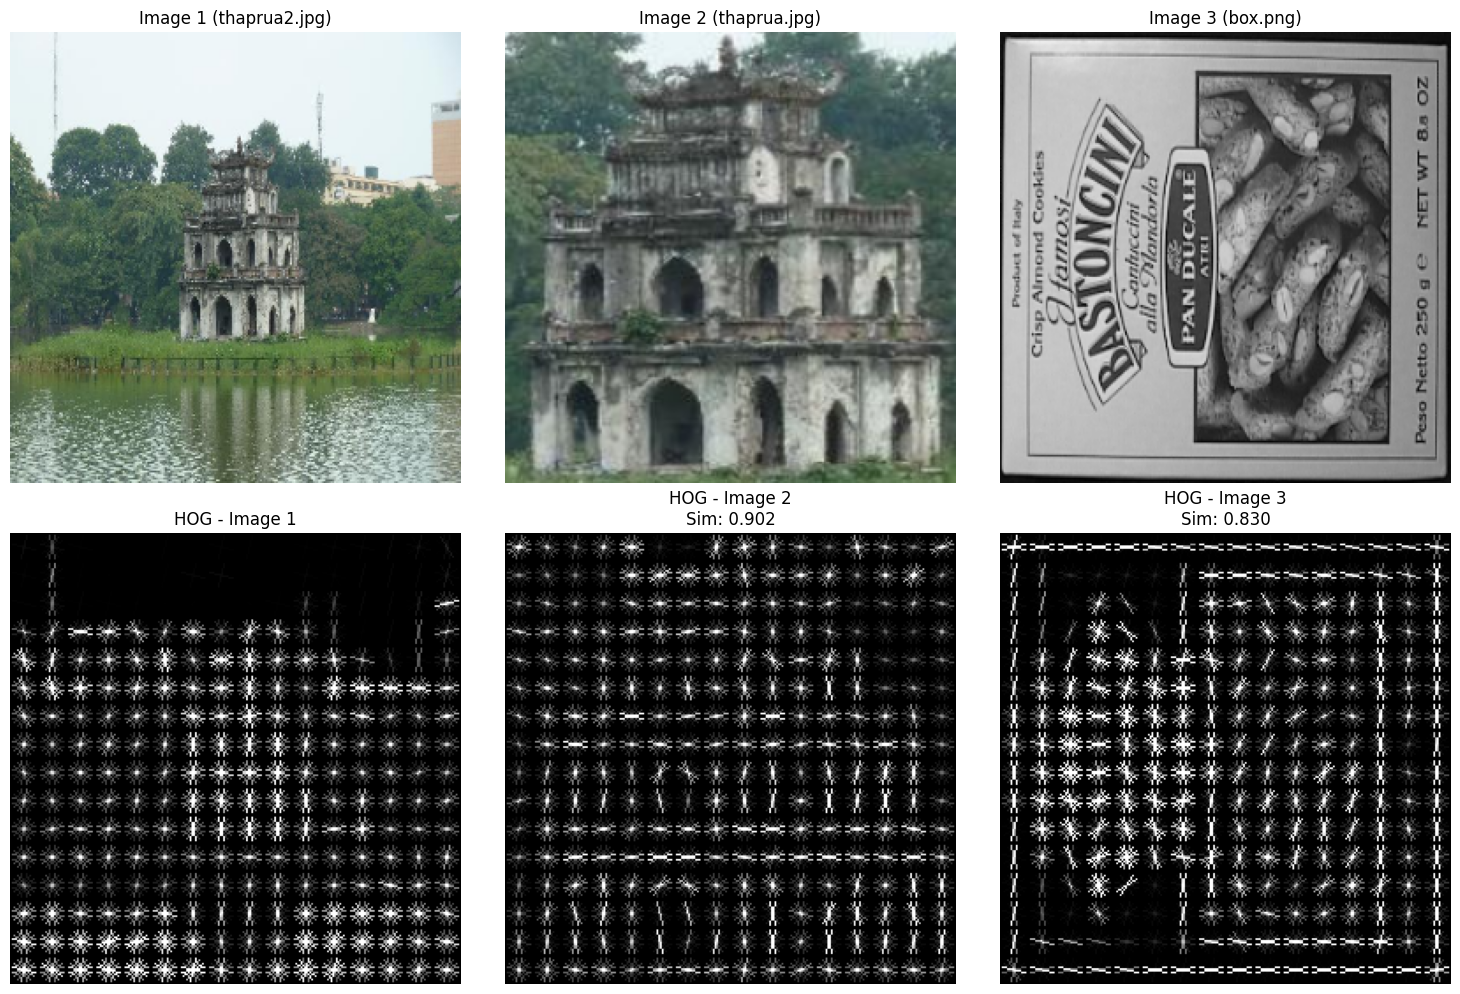

In [36]:
# Use HoG to compare 2 images, show the similarity
image2 = cv2.imread('images/thaprua.jpg')
image1 = cv2.imread('images/thaprua2.jpg')
image3 = cv2.imread('images/box.png')

target_size = (256, 256)
image1_resized = cv2.resize(image1, target_size)
image2_resized = cv2.resize(image2, target_size)
image3_resized = cv2.resize(image3, target_size)

fd1, hog1 = hog(image1_resized, orientations=8, pixels_per_cell=(16, 16),
                cells_per_block=(1, 1), visualize=True, channel_axis=2)
fd2, hog2 = hog(image2_resized, orientations=8, pixels_per_cell=(16, 16),
                cells_per_block=(1, 1), visualize=True, channel_axis=2)
fd3, hog3 = hog(image3_resized, orientations=8, pixels_per_cell=(16, 16),
                cells_per_block=(1, 1), visualize=True, channel_axis=2)


# Calculate similarity using Euclidean distance (smaller = more similar)
dist_1_2 = np.linalg.norm(fd1 - fd2)
dist_1_3 = np.linalg.norm(fd1 - fd3)
dist_2_3 = np.linalg.norm(fd2 - fd3)

# Calculate cosine similarity (closer to 1 = more similar)
cos_sim_1_2 = np.dot(fd1, fd2) / (np.linalg.norm(fd1) * np.linalg.norm(fd2))
cos_sim_1_3 = np.dot(fd1, fd3) / (np.linalg.norm(fd1) * np.linalg.norm(fd3))
cos_sim_2_3 = np.dot(fd2, fd3) / (np.linalg.norm(fd2) * np.linalg.norm(fd3))

print("HOG Feature Descriptor Shapes:")
print(f"Image 1: {fd1.shape}")
print(f"Image 2: {fd2.shape}")
print(f"Image 3: {fd3.shape}")
print("\n" + "="*50)
print("Euclidean Distance (smaller = more similar):")
print(f"Image1 vs Image2: {dist_1_2:.2f}")
print(f"Image1 vs Image3: {dist_1_3:.2f}")
print(f"Image2 vs Image3: {dist_2_3:.2f}")
print("\n" + "="*50)
print("Cosine Similarity (closer to 1 = more similar):")
print(f"Image1 vs Image2: {cos_sim_1_2:.4f}")
print(f"Image1 vs Image3: {cos_sim_1_3:.4f}")
print(f"Image2 vs Image3: {cos_sim_2_3:.4f}")

# Visualize the images and their HOG representations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original images
axes[0, 0].imshow(cv2.cvtColor(image1_resized, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Image 1 (thaprua2.jpg)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(image2_resized, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Image 2 (thaprua.jpg)')
axes[0, 1].axis('off')

axes[0, 2].imshow(cv2.cvtColor(image3_resized, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('Image 3 (box.png)')
axes[0, 2].axis('off')

# HOG visualizations
hog1_rescaled = skimage.exposure.rescale_intensity(hog1, in_range=(0, 10))
hog2_rescaled = skimage.exposure.rescale_intensity(hog2, in_range=(0, 10))
hog3_rescaled = skimage.exposure.rescale_intensity(hog3, in_range=(0, 10))

axes[1, 0].imshow(hog1_rescaled, cmap=plt.cm.gray)
axes[1, 0].set_title(f'HOG - Image 1')
axes[1, 0].axis('off')

axes[1, 1].imshow(hog2_rescaled, cmap=plt.cm.gray)
axes[1, 1].set_title(f'HOG - Image 2\nSim: {cos_sim_1_2:.3f}')
axes[1, 1].axis('off')

axes[1, 2].imshow(hog3_rescaled, cmap=plt.cm.gray)
axes[1, 2].set_title(f'HOG - Image 3\nSim: {cos_sim_1_3:.3f}')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## III. Scale-Invariant Feature Transform (SIFT) – Local features

* Detect keypoints using Difference of Gaussians (DoG)
* Describe keypoints using SIFT descriptors

The OpenCV library provides functions for extracting SIFT features:
[https://docs.opencv.org/3.4/d5/d3c/classcv_1_1xfeatures2d_1_1SIFT.html](https://docs.opencv.org/3.4/d5/d3c/classcv_1_1xfeatures2d_1_1SIFT.html)

To initialize a SIFT object in OpenCV, use:

```python
sift = cv2.xfeatures2d.SIFT_create()
```

From version 4.4 onward, SIFT is no longer subject to patent restrictions, and the SIFT object can be created using:

```python
sift = cv2.SIFT_create()
```

[https://docs.opencv.org/4.4.0/d7/d60/classcv_1_1SIFT.html](https://docs.opencv.org/4.4.0/d7/d60/classcv_1_1SIFT.html)

This object provides the method **`detectAndCompute()`**, which returns two outputs:

* **`kp`** – a list of keypoints detected by SIFT
* **`des`** – a NumPy array containing `len(kp)` vectors of 128 dimensions

These features can be used for object detection and image classification tasks.


Number of keypoints: 878
(2.8765766620635986, 204.2153778076172)
2.3521835803985596
119.755615234375
Descriptor shape =  (878, 128)
Descriptor size =  128


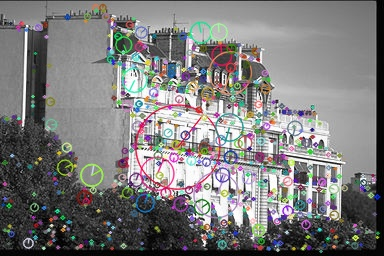

In [37]:
img = cv2.imread('images/ville01002.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#sift = cv2.xfeatures2d.SIFT_create() #up to version OpenCV 3.4.2: (pip uninstall opencv-python pip uninstall opencv-contrib-python pip install opencv-contrib-python==3.4.2.17)
sift = cv2.SIFT_create() ; # from OpenCV 4.0 (?4.5)

kp, des = sift.detectAndCompute(gray, None)

print('Number of keypoints:', len(kp))
print(kp[0].pt)
print(kp[0].size)
print(kp[0].angle)

print('Descriptor shape = ', des.shape)
print('Descriptor size = ', sift.descriptorSize())

#img=cv2.drawKeypoints(gray,kp,img)
img=cv2.drawKeypoints(gray,kp,img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

#img_final = cv2.drawKeypoints(img, keypoint, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

cv2.imwrite('sift_keypoints.jpg',img)
Image('sift_keypoints.jpg')

## I## IV. Speeded-Up Robust Features (SURF) – Local features

*(Faster than SIFT)*

* Keypoint detection
* SURF keypoint descriptors

If the version you are currently using has issues with this part, you may temporarily skip it and review the additional installation steps later (consider it as a homework task).


In [38]:
img = cv2.imread('images/box.png', 0)

try:
    # Try SURF first
    minHessian = 400
    detector = cv2.xfeatures2d.SURF_create(hessianThreshold=minHessian)
    print("Using SURF detector")
except AttributeError:
    # Fall back to SIFT if SURF is not available
    detector = cv2.SIFT_create()
    print("SURF not available, using SIFT detector")

keypoints = detector.detect(img)

# -- Draw keypoints
img_keypoints = np.empty((img.shape[0], img.shape[1], 3), dtype=np.uint8)
cv2.drawKeypoints(img, keypoints, img_keypoints)

cv2.imwrite('surf_or_sift_keypoints.jpg', img_keypoints)
Image('surf_or_sift_keypoints.jpg')

# More Ref: https://docs.opencv.org/3.4/df/dd2/tutorial_py_surf_intro.html

error: OpenCV(4.13.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv_contrib/modules/xfeatures2d/src/surf.cpp:1028: error: (-213:The function/feature is not implemented) This algorithm is patented and is excluded in this configuration; Set OPENCV_ENABLE_NONFREE CMake option and rebuild the library in function 'create'


## V. Image Matching using SIFT

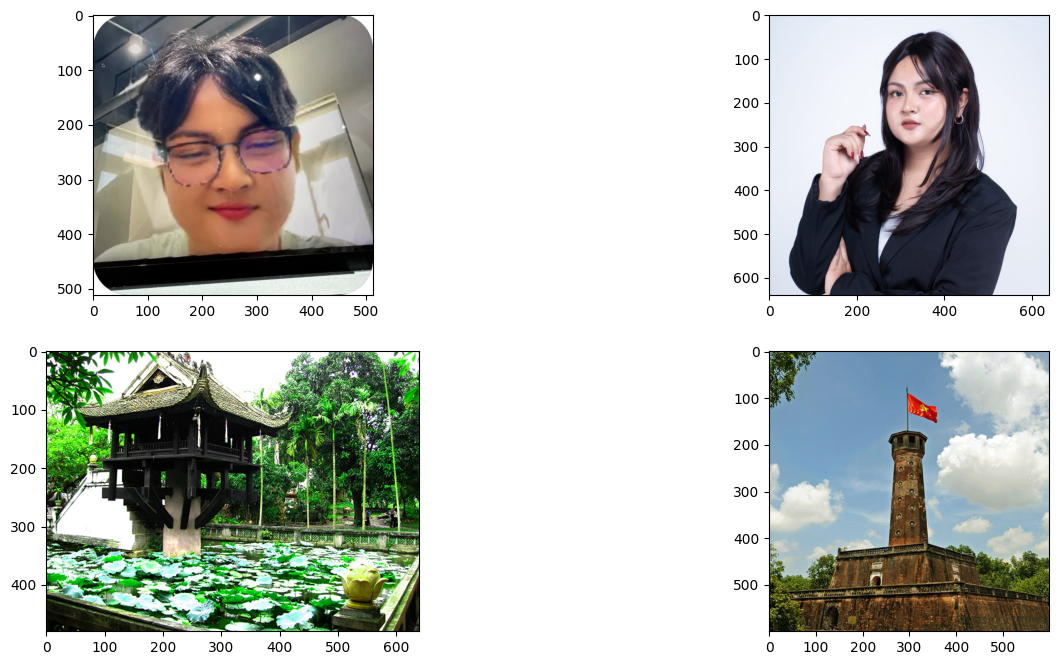

In [ ]:
img1 = cv2.imread('images/ahdom/dom.jpeg')
img2 = cv2.imread('images/ahdom/2026-01-09 09.20.02.jpg')
img3 = cv2.imread('images/chuamotcot.jpg')
img4 = cv2.imread('images/cotco.jpg')

img1_ = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_ = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3_ = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4_ = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,8))

plt.subplot(221), plt.imshow(img1_)
plt.subplot(222), plt.imshow(img2_)
plt.subplot(223), plt.imshow(img3_)
plt.subplot(224), plt.imshow(img4_) 
plt.show()

In [ ]:
# # tạo bộ trích chọn đặc trưng
# sift = cv2.xfeatures2d.SIFT_create()

# # tìm điểm đặc trưng và tính sift cho từng ảnh
# kp1, des1 = sift.detectAndCompute(img1,None)
# kp2, des2 = sift.detectAndCompute(img2,None)
# kp3, des3 = sift.detectAndCompute(img3,None)
# kp4, des4 = sift.detectAndCompute(img4,None)

In [39]:
# tạo bộ trích chọn đặc trưng
# sift = cv2.xfeatures2d.SIFT_create()
sift = cv2.SIFT_create() ; # from OpenCV 4.0 (?4.5)

# tìm điểm đặc trưng và tính sift cho từng ảnh
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
kp3, des3 = sift.detectAndCompute(img3,None)
kp4, des4 = sift.detectAndCompute(img4,None)


* **FLANN** stands for **Fast Library for Approximate Nearest Neighbors**. It contains a collection of algorithms optimized for fast nearest-neighbor searches in large datasets.

[https://github.com/flann-lib/flann](https://github.com/flann-lib/flann)
[http://opencv.jp/opencv-2svn_org/cpp/flann_fast_approximate_nearest_neighbor_search.html](http://opencv.jp/opencv-2svn_org/cpp/flann_fast_approximate_nearest_neighbor_search.html)


In [40]:
## Find matching feature pairs between two images. You can use either the **BRUTE_FORCE** matching method or **FLANN** to support faster matching.

FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params,search_params)

matches2 = flann.knnMatch(des1,des2,k=2) # Return the **two nearest features** from the set `des2`.


MIN_MATCH_COUNT=10
good = []
distance_ratio = 0.7
for m,n in matches2:
    if m.distance < distance_ratio*n.distance: # Keep only the **stable matches**, where `m.distance` is the distance to the closest match and `n.distance` is the distance to the second-closest match.

        good.append(m)

Use the **RANSAC** or **LEAST_MEDIAN** algorithm from the function **`cv2.findHomography`** to specify the region of the detected object.

In [41]:
## Draw a **bounding region around the detected object**.

if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    
    # Find the **homography transformation** between the two sets of matched points.

    ### YOUR CODE HERE
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0) 
    ### YOUR CODE HERE
    
    matchesMask = mask.ravel().tolist()
    h,w,d = img1.shape
    
    # Determine the corresponding positions on the **target image** of the four corners of the **source image**.
    
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2) # 4 điểm khoanh vùng trên ảnh nguồn
    ### YOUR CODE HERE
    dst = cv2.perspectiveTransform(pts, M) # Perform the **transformation** to find the corresponding positions in the matched image.

    ### YOUR CODE HERE
    
    # Display the **corresponding results**.
    img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)
else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None

In [42]:
## khoanh vùng đối tượng tương ứng được tìm thấy
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    
    # tìm phép biến đổi đồng dạng giữa 2 tập điểm được so khớp
    ### YOUR CODE HERE (see cv2.findHomography)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0) 
    ### YOUR CODE HERE
    
    matchesMask = mask.ravel().tolist()
    h,w,d = img1.shape
    
    # xác định vị trí tương ứng trên ảnh đích của 4 góc trên ảnh nguồn
    
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2) # 4 điểm khoanh vùng trên ảnh nguồn
    ### YOUR CODE HERE (see cv2.perspectiveTransform)
    dst = cv2.perspectiveTransform(pts,M) # thực hiện biến đổi để tìm ra vị trí tương ứng trong ảnh được so khớp
    ### YOUR CODE HERE
    
    # hiển thị kết quả tương ứng
    img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)
else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None

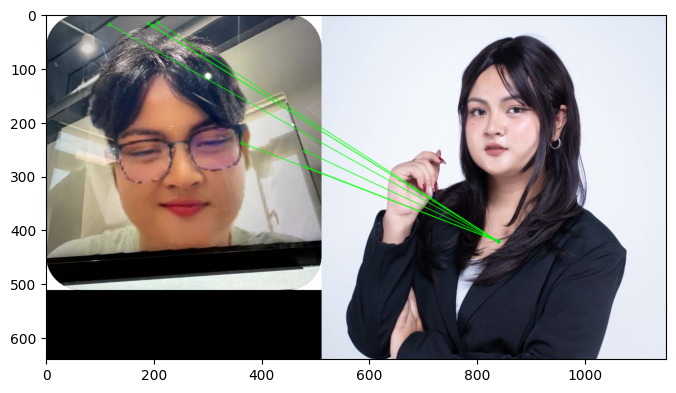

In [43]:
## Results
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)
img12 = cv2.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img12, cv2.COLOR_BGR2RGB))
plt.show()

## Perform matching between other image pairs (**img1, img3**) and (**img1, img4**)

Students can rewrite the process as a **function** for cleaner and reusable code.


In [44]:
def ImageMatching(img1, img2, distance_ratio):
    
    img2_copy = img2.copy()
    
    # Create SIFT detector
    sift = cv2.SIFT_create()
    
    # Find keypoints and compute SIFT descriptors
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    # Setup FLANN matcher
    FLANN_INDEX_KDTREE = 0
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # Find matches using KNN (k=2 for Lowe's ratio test)
    matches = flann.knnMatch(des1, des2, k=2)
    
    # Apply Lowe's ratio test to filter good matches
    good = []
    for m, n in matches:
        if m.distance < distance_ratio * n.distance:
            good.append(m)
    
    MIN_MATCH_COUNT = 10
    
    # Draw bounding region around detected object
    if len(good) > MIN_MATCH_COUNT:
        # Extract matched point locations
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        
        # Find homography transformation using RANSAC
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()
        
        # Get dimensions of source image
        h, w, d = img1.shape
        
        # Define 4 corner points of source image
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        
        # Transform corner points to find corresponding positions in target image
        dst = cv2.perspectiveTransform(pts, M)
        
        # Draw bounding box on target image
        img2_copy = cv2.polylines(img2_copy, [np.int32(dst)], True, 255, 3, cv2.LINE_AA)
        
        print(f"Good matches found: {len(good)}/{MIN_MATCH_COUNT}")
    else:
        print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
        matchesMask = None
    
    # Draw matches
    draw_params = dict(matchColor=(0, 255, 0),  # Draw matches in green
                       singlePointColor=None,
                       matchesMask=matchesMask,  # Draw only inliers
                       flags=2)
    
    result_img = cv2.drawMatches(img1, kp1, img2_copy, kp2, good, None, **draw_params)
    
    # Display result
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Image Matching (distance_ratio={distance_ratio}, matches={len(good)})')
    plt.axis('off')
    plt.show()
    
    return result_img

Good matches found: 635/10


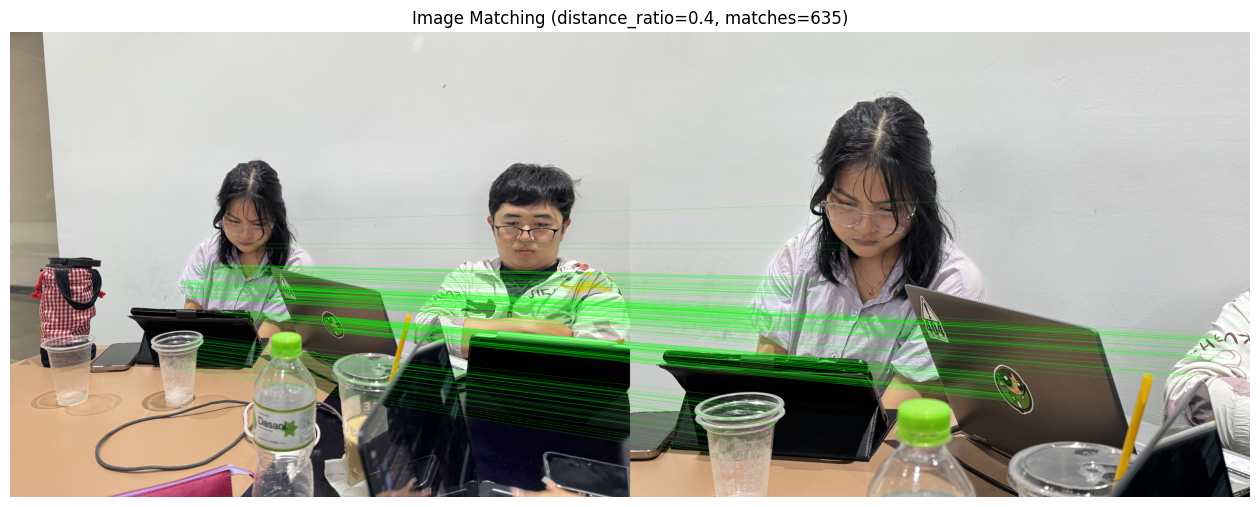

array([[[ 95, 110, 119],
        [ 97, 112, 121],
        [ 99, 114, 123],
        ...,
        [210, 212, 212],
        [204, 206, 206],
        [201, 203, 203]],

       [[ 97, 112, 121],
        [ 97, 112, 121],
        [ 98, 113, 122],
        ...,
        [210, 212, 212],
        [205, 207, 207],
        [204, 206, 206]],

       [[ 99, 114, 123],
        [ 97, 112, 121],
        [ 97, 112, 121],
        ...,
        [210, 212, 212],
        [207, 209, 209],
        [206, 208, 208]],

       ...,

       [[137, 176, 221],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[137, 176, 221],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[136, 175, 220],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [ ]:
ImageMatching(img1, img2, 0.4)

Good matches found: 172/10


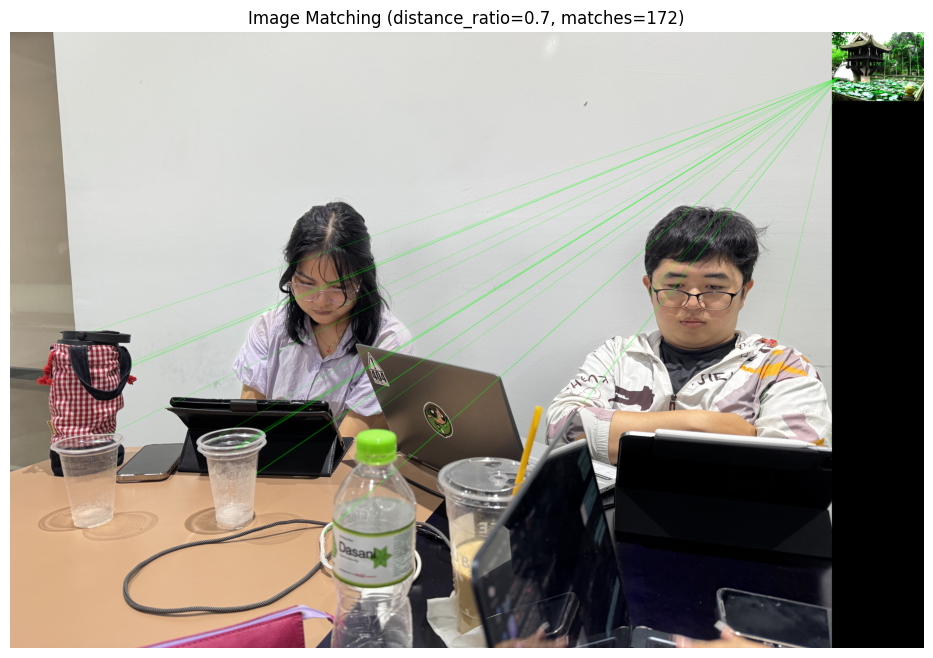

array([[[ 95, 110, 119],
        [ 97, 112, 121],
        [ 99, 114, 123],
        ...,
        [ 36,  79,  58],
        [  9, 166,  46],
        [  0, 226,  37]],

       [[ 97, 112, 121],
        [ 97, 112, 121],
        [ 98, 113, 122],
        ...,
        [ 39, 112,  80],
        [ 23, 203,  78],
        [ 30, 242,  69]],

       [[ 99, 114, 123],
        [ 97, 112, 121],
        [ 97, 112, 121],
        ...,
        [132, 194, 164],
        [ 53, 222, 106],
        [ 79, 229, 106]],

       ...,

       [[137, 176, 221],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[137, 176, 221],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[136, 175, 220],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [ ]:
ImageMatching(img1, img3, 0.7)

Not enough matches are found - 10/10


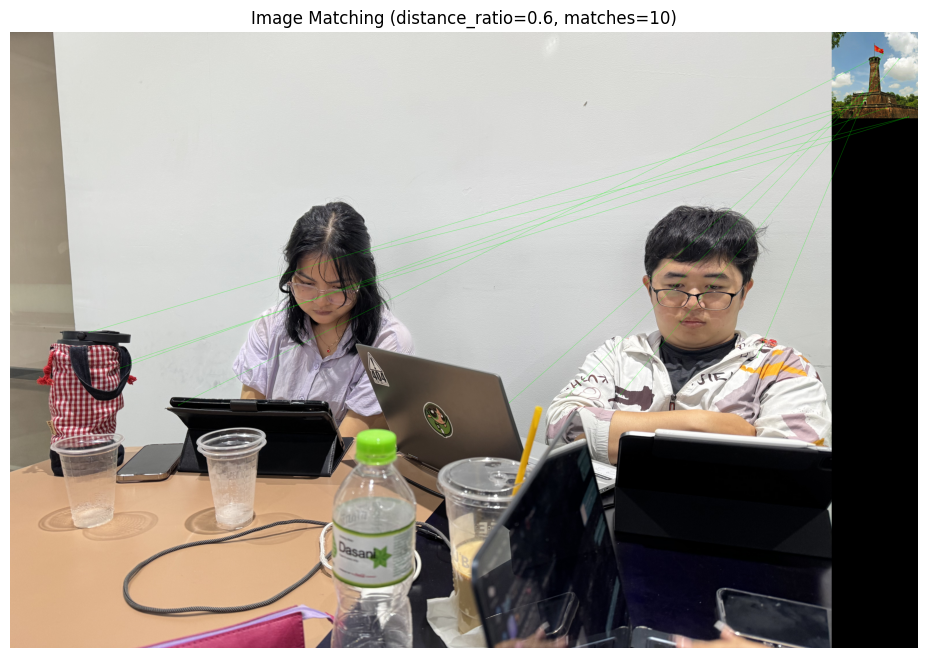

array([[[ 95, 110, 119],
        [ 97, 112, 121],
        [ 99, 114, 123],
        ...,
        [185, 168, 142],
        [186, 168, 145],
        [186, 167, 146]],

       [[ 97, 112, 121],
        [ 97, 112, 121],
        [ 98, 113, 122],
        ...,
        [187, 170, 144],
        [187, 169, 146],
        [188, 169, 148]],

       [[ 99, 114, 123],
        [ 97, 112, 121],
        [ 97, 112, 121],
        ...,
        [188, 171, 145],
        [188, 170, 147],
        [188, 169, 148]],

       ...,

       [[137, 176, 221],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[137, 176, 221],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[136, 175, 220],
        [136, 175, 220],
        [136, 175, 220],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [ ]:
 ImageMatching(img1, img4, 0.6)

### Perform matching of 2 images using **SURF** local features


In [ ]:
# Perform matching of 2 images using **SURF** local features

def ImageMatchingSURF(img1, img2, distance_ratio=0.7, hessianThreshold=400):


    img2_copy = img2.copy()

    # Try to create SURF detector, fall back to SIFT if not available
    try:
        detector = cv2.xfeatures2d.SURF_create(
            hessianThreshold=hessianThreshold)
        print("Using SURF detector")
    except AttributeError:
        detector = cv2.SIFT_create()
        print("SURF not available, falling back to SIFT detector")

    # Find keypoints and compute descriptors
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    print(f"Keypoints detected - Image 1: {len(kp1)}, Image 2: {len(kp2)}")

    # Setup FLANN matcher
    FLANN_INDEX_KDTREE = 0
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Find matches using KNN (k=2 for Lowe's ratio test)
    matches = flann.knnMatch(des1, des2, k=2)

    # Apply Lowe's ratio test to filter good matches
    good = []
    for m, n in matches:
        if m.distance < distance_ratio * n.distance:
            good.append(m)

    MIN_MATCH_COUNT = 10

    # Draw bounding region around detected object
    if len(good) > MIN_MATCH_COUNT:
        # Extract matched point locations
        src_pts = np.float32(
            [kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32(
            [kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        # Find homography transformation using RANSAC
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()

        # Get dimensions of source image
        h, w, d = img1.shape

        # Define 4 corner points of source image
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1],
                         [w-1, 0]]).reshape(-1, 1, 2)

        # Transform corner points to find corresponding positions in target image
        dst = cv2.perspectiveTransform(pts, M)

        # Draw bounding box on target image
        img2_copy = cv2.polylines(
            img2_copy, [np.int32(dst)], True, (0, 255, 0), 3, cv2.LINE_AA)

        print(f"Good matches found: {len(good)}/{MIN_MATCH_COUNT}")
    else:
        print(f"Not enough matches are found - {len(good)}/{MIN_MATCH_COUNT}")
        matchesMask = None

    # Draw matches
    draw_params = dict(matchColor=(0, 255, 0),  # Draw matches in green
                       singlePointColor=None,
                       matchesMask=matchesMask,  # Draw only inliers
                       flags=2)

    result_img = cv2.drawMatches(
        img1, kp1, img2_copy, kp2, good, None, **draw_params)

    # Display result
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    detector_name = "SURF" if "SURF" in str(type(detector)) else "SIFT"
    plt.title(
        f'Image Matching using {detector_name} (distance_ratio={distance_ratio}, matches={len(good)})')
    plt.axis('off')
    plt.show()

    return result_img


# Test SURF matching with different image pairs
print("=" * 60)
print("Testing SURF matching: img1 vs img2")
print("=" * 60)

Testing SURF matching: img1 vs img2


## VI. Panorama Stitching
**Application: Creating a panorama using local features**

To generate a high-quality panorama, multiple steps are required. The **Stitcher** is implemented in OpenCV.

OpenCV already provides a method similar to Brown and Lowe’s paper via:

* `cv2.createStitcher()` (OpenCV 3.x)
* `cv2.Stitcher_create()` (OpenCV 4)


Ref: http://matthewalunbrown.com/papers/ijcv2007.pdf

In [ ]:
!pip install imutils

In [ ]:
import imutils

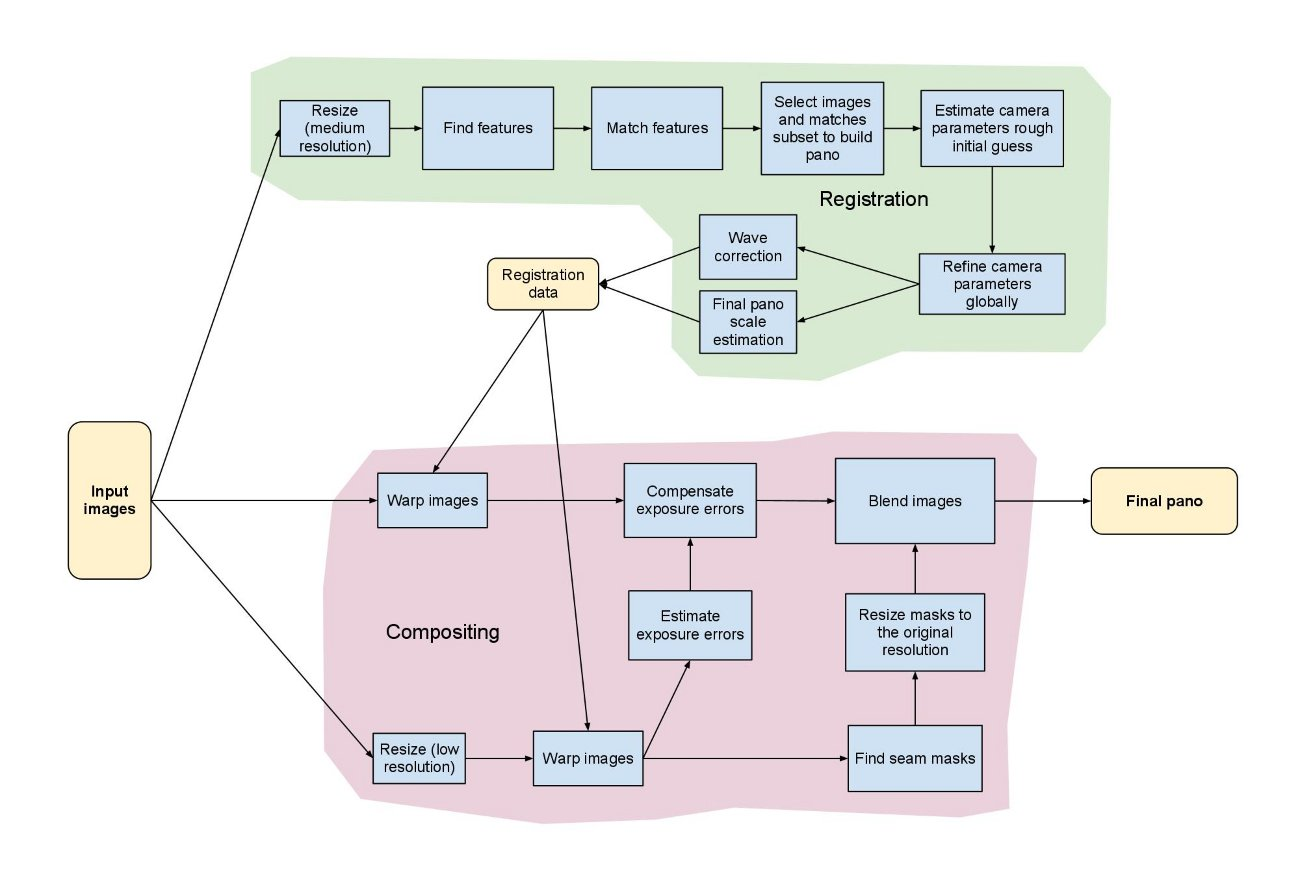

In [ ]:
Image('images/StitchingPipeline.jpg')

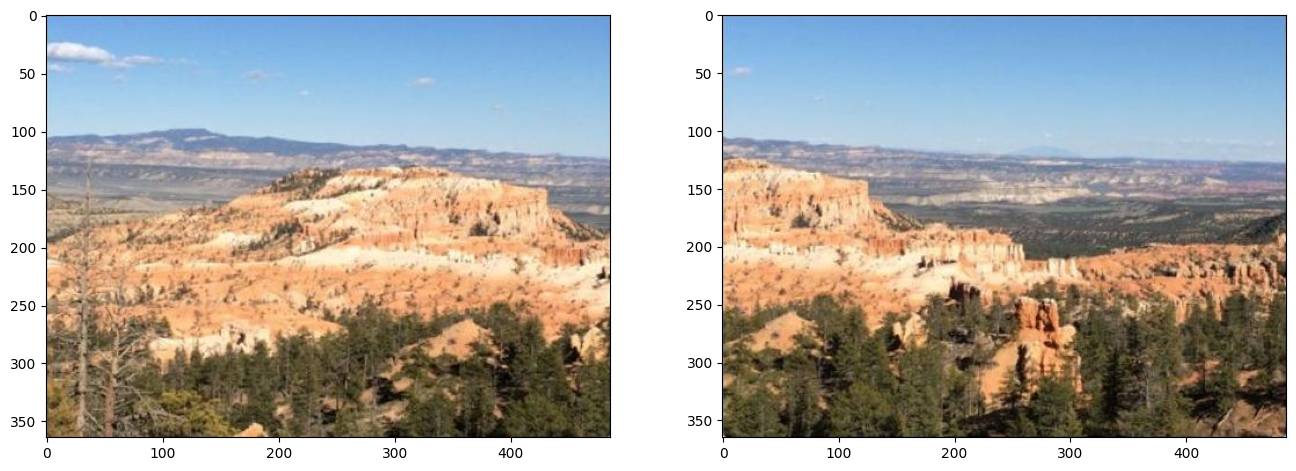

In [ ]:
imageA = cv2.imread('./images/panonama/imageA.jpeg')
imageB = cv2.imread('./images/panonama/imageB.jpeg')

plt.figure(figsize=(16,16))
plt.subplot(121), plt.imshow(cv2.cvtColor(imageA, cv2.COLOR_BGR2RGB))
plt.subplot(122), plt.imshow(cv2.cvtColor(imageB, cv2.COLOR_BGR2RGB))
plt.show()

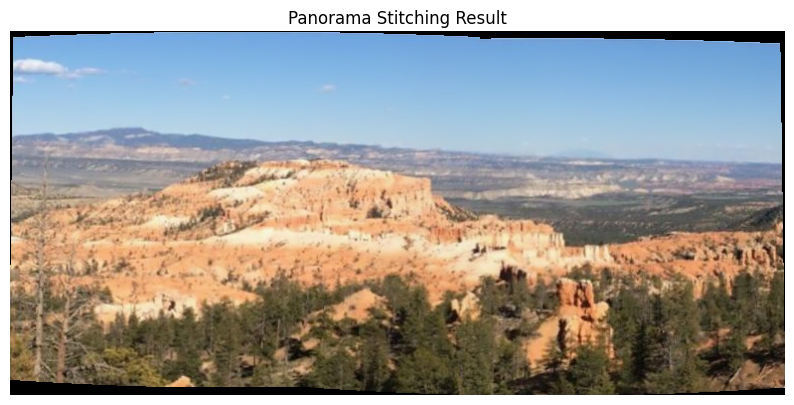

In [ ]:
# OpenCV has already implemented a method similar to Brown and Lowe’s paper 
# via the cv2.createStitcher (OpenCV 3.x) and cv2.Stitcher_create (OpenCV 4) functions.

# stitcher = cv2.createStitcher('SCANS', False)
# stitcher = cv2.createStitcher(False) # (OpenCV 3.x)
# stitcher = cv2.Stitcher_create() # (OpenCV 4)
#stitcher = cv2.Stitcher.create()



stitcher = cv2.createStitcher() if imutils.is_cv3() else cv2.Stitcher_create()

result = stitcher.stitch((imageA, imageB))

# Check if stitching was successful
status = result[0]
if status == 0:  # cv2.Stitcher_OK
    stitched = result[1]
    cv2.imwrite('./images/panonama/pana_r.jpeg', stitched)
    
    # Display the result
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
    plt.title('Panorama Stitching Result')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: Stitching failed with status code {status}")
    print("Status codes: 0=OK, 1=ERR_NEED_MORE_IMGS, 2=ERR_HOMOGRAPHY_EST_FAIL, 3=ERR_CAMERA_PARAMS_ADJUST_FAIL")

### Xử lý viền ngoài ảnh

In [45]:
# create a 10 pixel border surrounding the stitched image
stitched = cv2.copyMakeBorder(stitched, 10, 10, 10, 10,cv2.BORDER_CONSTANT, (0, 0, 0)) 

# convert the stitched image to grayscale and threshold it
# such that all pixels greater than zero are set to 255
# (foreground) while all others remain 0 (background)
gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)[1]

# find all external contours in the threshold image then find
# the *largest* contour which will be the contour/outline of
# the stitched image
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key=cv2.contourArea)

# allocate memory for the mask which will contain the rectangular bounding box of the stitched image region
mask = np.zeros(thresh.shape, dtype="uint8")
(x, y, w, h) = cv2.boundingRect(c)
cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)

# create two copies of the mask: one to serve as our actual
# minimum rectangular region and another to serve as a counter
# for how many pixels need to be removed to form the minimum
# rectangular region
minRect = mask.copy()
sub = mask.copy()
while cv2.countNonZero(sub) > 0:
    # erode the minimum rectangular mask and then subtract
	# the thresholded image from the minimum rectangular mask
	# so we can count if there are any non-zero pixels left
    minRect = cv2.erode(minRect, None)
    sub = cv2.subtract(minRect, thresh)
    
# find contours in the minimum rectangular mask and then
# extract the bounding box (x, y)-coordinates    
cnts = cv2.findContours(minRect.copy(), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key=cv2.contourArea)
(x, y, w, h) = cv2.boundingRect(c)

# use the bounding box coordinates to extract the our final
# stitched image
stitched = stitched[y:y + h, x:x + w]

# write the output stitched image to disk
cv2.imwrite('mountain1_stic.png', stitched)

#Image('mountain1_stic.png')
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
plt.show()

NameError: name 'stitched' is not defined

## VII. Check if Two Images are Twins (Similar)

In [46]:
def check_if_twins(img1, img2, distance_ratio=0.7, min_matches_threshold=15):
    """
    Check if two images are twins (similar) based on SIFT feature matching.
    
    Parameters:
    - img1, img2: Input images (BGR format)
    - distance_ratio: Ratio threshold for Lowe's ratio test (default 0.7)
    - min_matches_threshold: Minimum good matches required to consider twins (default 15)
    
    Returns:
    - Dictionary with:
        - 'are_twins': Boolean (True if images are twins)
        - 'confidence': Float between 0-1 indicating similarity confidence
        - 'good_matches': Number of good matches found
        - 'total_keypoints_1': Total keypoints in image 1
        - 'total_keypoints_2': Total keypoints in image 2
        - 'match_ratio': Percentage of matched keypoints
    """
    
    # Create SIFT detector
    sift = cv2.SIFT_create()
    
    # Find keypoints and descriptors
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    # Handle case where no descriptors are found
    if des1 is None or des2 is None:
        return {
            'are_twins': False,
            'confidence': 0.0,
            'good_matches': 0,
            'total_keypoints_1': len(kp1) if kp1 else 0,
            'total_keypoints_2': len(kp2) if kp2 else 0,
            'match_ratio': 0.0,
            'message': 'No descriptors found in one or both images'
        }
    
    # Setup FLANN matcher
    FLANN_INDEX_KDTREE = 0
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # Find matches using KNN (k=2)
    matches = flann.knnMatch(des1, des2, k=2)
    
    # Apply Lowe's ratio test
    good = []
    for m, n in matches:
        if m.distance < distance_ratio * n.distance:
            good.append(m)
    
    # Calculate metrics
    total_keypoints = max(len(kp1), len(kp2))
    match_ratio = (len(good) / total_keypoints * 100) if total_keypoints > 0 else 0
    
    # Calculate confidence score (0-1)
    # Based on: number of matches and match ratio
    confidence = min(len(good) / 50, 1.0) * (match_ratio / 20)
    confidence = min(confidence, 1.0)
    
    # Determine if they are twins
    are_twins = len(good) >= min_matches_threshold and match_ratio > 10
    
    return {
        'are_twins': are_twins,
        'confidence': round(confidence, 3),
        'good_matches': len(good),
        'total_keypoints_1': len(kp1),
        'total_keypoints_2': len(kp2),
        'match_ratio': round(match_ratio, 2),
        'message': f"Images are {'TWINS' if are_twins else 'NOT TWINS'} ({len(good)} good matches found)"
    }


# Test the function
def test_twins_detection():
    """Test the twin detection function with sample images"""
    
    # Read test images
    img1 = cv2.imread('images/ahdom/IMG_4715.jpeg')
    img2 = cv2.imread('images/ahdom/IMG_4716.jpeg')
    img3 = cv2.imread('images/chuamotcot.jpg')
    
    if img1 is None or img2 is None or img3 is None:
        print("Error: Could not load images")
        return
    
    print("=" * 70)
    print("TWIN DETECTION TEST RESULTS")
    print("=" * 70)
    
    # Test 1: Similar images (should be twins)
    print("\n[TEST 1] Similar images (IMG_4715 vs IMG_4716)")
    print("-" * 70)
    result1 = check_if_twins(img1, img2)
    for key, value in result1.items():
        print(f"  {key:.<25} {value}")
    
    # Test 2: Different images (should NOT be twins)
    print("\n[TEST 2] Different images (IMG_4715 vs chuamotcot)")
    print("-" * 70)
    result2 = check_if_twins(img1, img3)
    for key, value in result2.items():
        print(f"  {key:.<25} {value}")
    
    # Test 3: Different images (should NOT be twins)
    print("\n[TEST 3] Different images (IMG_4716 vs chuamotcot)")
    print("-" * 70)
    result3 = check_if_twins(img2, img3)
    for key, value in result3.items():
        print(f"  {key:.<25} {value}")
    
    print("\n" + "=" * 70)


# Run tests
test_twins_detection()


TWIN DETECTION TEST RESULTS

[TEST 1] Similar images (IMG_4715 vs IMG_4716)
----------------------------------------------------------------------
  are_twins................ False
  confidence............... 0.272
  good_matches............. 1945
  total_keypoints_1........ 34854
  total_keypoints_2........ 35807
  match_ratio.............. 5.43
  message.................. Images are NOT TWINS (1945 good matches found)

[TEST 2] Different images (IMG_4715 vs chuamotcot)
----------------------------------------------------------------------
  are_twins................ False
  confidence............... 0.025
  good_matches............. 172
  total_keypoints_1........ 34854
  total_keypoints_2........ 4108
  match_ratio.............. 0.49
  message.................. Images are NOT TWINS (172 good matches found)

[TEST 3] Different images (IMG_4716 vs chuamotcot)
----------------------------------------------------------------------
  are_twins................ False
  confidence..........